# CatchFish — Real-World Phishing Detection Pipeline (Google Colab)

**What this notebook does:**
- Loads all CSV datasets from `dataset/` (auto-discovered, schema A & B supported)
- Engineers 19 numeric + 3 text features — **identical to `train.py`**
- Trains 5 classifiers with the same hyperparameters as `train.py`
- Evaluates with AUC, Average Precision, F1@threshold, FP, FN
- Plots ROC, PR curves, confusion matrices, bar charts
- Saves `phishing_detection.pkl` — **drop-in replacement for `models/`**

> All random seeds, split ratios, feature engineering, and model hyperparameters
> are kept byte-for-byte identical with `train.py` so both produce the same model.

In [ ]:
# ── CELL 1 — Setup ──────────────────────────────────────────────────────────
import os

DATASET_PATH = '/content/dataset'
THRESHOLD    = 0.60   # ← change to match your .env PHISHING_THRESHOLD

assert os.path.isdir(DATASET_PATH), f'Dataset folder not found: {DATASET_PATH}'
print('✓ Dataset folder found:')
for f in sorted(os.listdir(DATASET_PATH)):
    print(f'  {f}')

✓ Dataset folder found:
  Enron.csv
  Ling.csv
  Nazario.csv
  Nigerian_Fraud.csv
  SpamAssasin.csv
  dataset1.csv
  dataset2.csv
  dataset3.csv
  dataset4.csv
  dataset5.csv
  legitimate_domains.json
  suspicious_tlds.json
  url_shorteners.json


In [ ]:
# ── CELL 2 — Install packages ───────────────────────────────────────────────
!pip install -q xgboost
print('✓ Packages ready')

✓ Packages ready


In [ ]:
# ── CELL 3 — Imports & reference data (embedded, no JSON files needed) ──────
import re, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 110
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.preprocessing import StandardScaler
import joblib

# ── Reference data — load from uploaded dataset/ folder ─────────────────────
def _load_json_set(path, key):
    if os.path.exists(path):
        with open(path, encoding='utf-8') as f:
            return set(json.load(f).get(key, []))
    return set()

LEGITIMATE_DOMAINS = _load_json_set(f'{DATASET_PATH}/legitimate_domains.json', 'domains')
SUSPICIOUS_TLDS    = _load_json_set(f'{DATASET_PATH}/suspicious_tlds.json',    'tlds')
URL_SHORTENERS     = _load_json_set(f'{DATASET_PATH}/url_shorteners.json',     'shorteners')

print(f'Legitimate domains : {len(LEGITIMATE_DOMAINS)}')
print(f'Suspicious TLDs    : {len(SUSPICIOUS_TLDS)}')
print(f'URL shorteners     : {len(URL_SHORTENERS)}')

# ── 24-entry urgency lexicon — MUST match train.py / app.py exactly ──────────
URGENT_KEYWORDS = [
    "urgent", "immediate", "action required", "verify now",
    "security alert", "account suspended", "password expired",
    "click here", "limited time", "offer expires", "verify account",
    "confirm identity", "unusual activity", "unauthorized access",
    "your account", "win a prize", "congratulations you", "claim now",
    "update your", "log in now", "sign in now", "confirm your",
    "verify", "suspended",
]

# ── 19 numeric feature names — MUST match NUMERIC_FEATURES in train.py ───────
NUMERIC_FEATURES = [
    "has_attachment", "links_count", "urgent_keywords",
    "email_length", "subject_length", "link_density",
    "domain_age", "special_chars", "html_tags",
    "legitimate_domain", "suspicious_tld",
    "ip_url_count", "shortener_url_count",
    "https_url_count", "http_url_count", "http_ratio",
    "domain_length", "domain_has_digits", "domain_has_hyphen",
]

print(f'\n✓ Reference data loaded  |  THRESHOLD = {THRESHOLD}')

Legitimate domains : 66
Suspicious TLDs    : 59
URL shorteners     : 84

✓ Reference data loaded  |  THRESHOLD = 0.6


In [ ]:
# ── CELL 4 — Cleaning helpers & universal CSV loader (identical to train.py) ─
HTML_TAG_RE = re.compile(r'<[^>]+>')
MULTI_WS_RE = re.compile(r'[ \t]+')
URL_RE      = re.compile(r'https?://[^\s]+', re.IGNORECASE)
SENDER_RE   = re.compile(r'[\w.\-+]+@([\w.\-]+\.\w{2,})')

LABEL_MAP = {
    '1':1,'phishing':1,'spam':1,'malicious':1,
    '0':0,'legitimate':0,'ham':0,'safe':0,'benign':0,
}

def _clean_text(text):
    if not isinstance(text, str):
        text = '' if pd.isna(text) else str(text)
    text = HTML_TAG_RE.sub(' ', text)
    text = text.replace('\r\n','\n').replace('\r','\n')
    return MULTI_WS_RE.sub(' ', text).strip()

def _extract_domain(sender):
    if not isinstance(sender, str) or not sender.strip(): return ''
    m = SENDER_RE.search(sender)
    if m: return m.group(1).lower().strip('.')
    if '@' in sender: return sender.split('@',1)[1].strip().lower().rstrip('>')
    return ''

def _count_links(text): return len(URL_RE.findall(str(text)))

def _count_urgent(subject, body):
    combined = (str(subject)+' '+str(body)).lower()
    return sum(1 for kw in URGENT_KEYWORDS if kw in combined)

def _to_numeric_col(series):
    return (pd.to_numeric(series.astype(str).str.strip().str.strip('"').str.strip("'"),
                          errors='coerce').fillna(0).astype(int))

def load_any_csv(fpath):
    raw = pd.read_csv(fpath, encoding='utf-8', on_bad_lines='skip')
    raw.columns = raw.columns.str.strip().str.strip('"').str.strip("'").str.lower()
    out = pd.DataFrame()
    lbl = raw['label'].astype(str).str.strip().str.strip('"').str.strip("'").str.lower()
    out['label'] = lbl.map(LABEL_MAP).fillna(0).astype(int)
    if 'email_text' in raw.columns:
        out['email_text'] = raw['email_text'].fillna('').apply(_clean_text)
    elif 'body' in raw.columns:
        out['email_text'] = raw['body'].fillna('').apply(_clean_text)
    else:
        out['email_text'] = ''
    out['subject'] = raw['subject'].fillna('').apply(_clean_text) if 'subject' in raw.columns else ''
    if 'sender_domain' in raw.columns:
        out['sender_domain'] = raw['sender_domain'].astype(str).str.strip().str.strip('"').str.strip("'").fillna('')
    elif 'sender' in raw.columns:
        out['sender_domain'] = raw['sender'].fillna('').apply(_extract_domain)
    else:
        out['sender_domain'] = ''
    out['has_attachment']  = _to_numeric_col(raw['has_attachment'])  if 'has_attachment'  in raw.columns else 0
    out['links_count']     = _to_numeric_col(raw['links_count'])     if 'links_count'     in raw.columns else out['email_text'].apply(_count_links)
    out['urgent_keywords'] = _to_numeric_col(raw['urgent_keywords']) if 'urgent_keywords' in raw.columns else out.apply(lambda r: _count_urgent(r['subject'],r['email_text']), axis=1)
    return out

_SYNTHETIC_RE = re.compile(r'^dataset\d+\.csv$', re.IGNORECASE)
ALL_CSV_FILES = sorted(f for f in os.listdir(DATASET_PATH)
                       if f.lower().endswith('.csv') and not _SYNTHETIC_RE.match(f))
print(f'Found {len(ALL_CSV_FILES)} CSV file(s): {ALL_CSV_FILES}')

Found 5 CSV file(s): ['Enron.csv', 'Ling.csv', 'Nazario.csv', 'Nigerian_Fraud.csv', 'SpamAssasin.csv']


In [ ]:
# ── CELL 5 — Load, normalise and merge all datasets ─────────────────────────
parts = []
for fname in ALL_CSV_FILES:
    fpath = os.path.join(DATASET_PATH, fname)
    try:
        part = load_any_csv(fpath)
        ph = int((part['label']==1).sum())
        lg = int((part['label']==0).sum())
        print(f'  {fname:30s} → {len(part):7,} rows  phishing={ph:,}  legitimate={lg:,}')
        parts.append(part)
    except Exception as e:
        print(f'  {fname:30s} → SKIPPED ({e})')

df = pd.concat(parts, ignore_index=True)
before = len(df)
df = df.drop_duplicates(subset=['email_text','subject'])
print(f'\nDuplicates removed : {before-len(df):,}')
df = df[~((df['email_text'].str.strip()=='') & (df['subject'].str.strip()==''))]
df['has_attachment']  = df['has_attachment'].astype(int)
df['links_count']     = df['links_count'].astype(int)
df['urgent_keywords'] = df['urgent_keywords'].astype(int)
df['sender_domain']   = df['sender_domain'].fillna('')
df['email_text']      = df['email_text'].fillna('')
df['subject']         = df['subject'].fillna('')
n_ph = int((df['label']==1).sum())
n_lg = int((df['label']==0).sum())
print(f'\nMerged total : {len(df):,} rows  phishing={n_ph:,}  legitimate={n_lg:,}')
display(df.head(3))

  Enron.csv                      →  29,767 rows  phishing=13,976  legitimate=15,791
  Ling.csv                       →   2,859 rows  phishing=458  legitimate=2,401
  Nazario.csv                    →   1,565 rows  phishing=1,565  legitimate=0
  Nigerian_Fraud.csv             →   3,332 rows  phishing=3,332  legitimate=0
  SpamAssasin.csv                →   5,809 rows  phishing=1,718  legitimate=4,091

Duplicates removed : 53

Merged total : 43,279 rows  phishing=20,996  legitimate=22,283


,label,email_text,subject,sender_domain,has_attachment,links_count,urgent_keywords
0,0,( see attached file : hplno 525 . xls )\n- hpl...,"hpl nom for may 25 , 2001",,0,0,0
1,0,- - - - - - - - - - - - - - - - - - - - - - fo...,re : nom / actual vols for 24 th,,0,0,0
2,0,"estimated actuals\nmarch 30 , 2001\nno flow\nm...","enron actuals for march 30 - april 1 , 201",,0,0,0


In [ ]:
# ── CELL 6 — extract_additional_features() — EXACT COPY of train.py ─────────
def extract_additional_features(df):
    df = df.copy()
    df['email_length']   = df['email_text'].apply(lambda x: len(str(x)))
    df['subject_length'] = df['subject'].apply(lambda x: len(str(x)))
    df['link_density']   = df['links_count'] / (df['email_length'] + 1)
    df['legitimate_domain'] = df['sender_domain'].apply(
        lambda x: 1 if str(x).lower().strip() in LEGITIMATE_DOMAINS else 0)
    df['suspicious_tld'] = df['sender_domain'].apply(
        lambda x: 1 if any(str(x).lower().strip().endswith(t) for t in SUSPICIOUS_TLDS) else 0)
    df['domain_length']     = df['sender_domain'].apply(lambda x: len(str(x)))
    df['domain_has_digits'] = df['sender_domain'].apply(lambda x: int(any(c.isdigit() for c in str(x))))
    df['domain_has_hyphen'] = df['sender_domain'].apply(lambda x: int('-' in str(x)))
    df['domain_age']        = df['sender_domain'].apply(
        lambda x: 30 if str(x).lower().strip() in LEGITIMATE_DOMAINS
        else max(1, abs(hash(str(x))) % 8 + 1))
    def count_ip_urls(t):   return len(re.findall(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', str(t).lower()))
    def count_shorteners(t):
        tl = str(t).lower()
        return sum(1 for s in URL_SHORTENERS if s in tl)
    def count_https(t): return len(re.findall(r'https://', str(t).lower()))
    def count_http(t):  return len(re.findall(r'http://', str(t).lower()))
    df['ip_url_count']        = df['email_text'].apply(count_ip_urls)
    df['shortener_url_count'] = df['email_text'].apply(count_shorteners)
    df['https_url_count']     = df['email_text'].apply(count_https)
    df['http_url_count']      = df['email_text'].apply(count_http)
    df['http_ratio']          = df['http_url_count'] / (df['links_count'] + 1)
    df['special_chars'] = df['email_text'].apply(
        lambda x: len(re.findall(r'[!$%^&*()_+|~=`{}\[\]:\"\'<>?,./]', str(x))))
    df['html_tags']     = df['email_text'].apply(
        lambda x: len(re.findall(r'<[^>]+>', str(x).lower())))
    return df

df = extract_additional_features(df)
print(f'Feature columns: {df.shape[1]}')
display(df[NUMERIC_FEATURES].describe().round(3))

Feature columns: 23


,has_attachment,links_count,urgent_keywords,email_length,subject_length,link_density,domain_age,special_chars,html_tags,legitimate_domain,suspicious_tld,ip_url_count,shortener_url_count,https_url_count,http_url_count,http_ratio,domain_length,domain_has_digits,domain_has_hyphen
count,43279.0,43279.000,43279.000,43279.000,43279.000,43279.000,43279.000,43279.000,43279.0,43279.000,43279.000,43279.000,43279.000,43279.000,43279.000,43279.000,43279.000,43279.000,43279.000
mean,0.0,0.586,0.292,1897.579,33.547,0.000,2.528,89.551,0.0,0.028,0.002,0.008,0.034,0.033,0.555,0.076,2.941,0.011,0.008
std,0.0,15.856,0.665,22885.183,42.811,0.001,4.968,1365.229,0.0,0.165,0.040,0.205,0.186,0.321,15.850,0.207,5.702,0.104,0.087
min,0.0,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.0,0.000,0.000,396.000,19.000,0.000,1.000,14.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.0,0.000,0.000,887.000,30.000,0.000,1.000,34.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.0,0.000,0.000,2031.000,44.000,0.000,1.000,79.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,0.0,3131.000,14.000,4550368.000,7169.000,0.026,30.000,193742.000,0.0,1.000,1.000,18.000,4.000,41.000,3131.000,2.500,56.000,1.000,1.000


In [ ]:
# ── CELL 7 — Train/test split & preprocessor — EXACT COPY of train.py ────────
X = df.drop('label', axis=1)
y = df['label']
n_phish = int(y.sum()); n_legit = int((y==0).sum())
print(f'Phishing: {n_phish:,}  |  Legitimate: {n_legit:,}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Sample weights for boosting models — same formula as train.py
w_phish = 1.0
w_legit = (n_phish / n_legit) * 1.4
sw_train = np.where(y_train == 1, w_phish, w_legit)
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'w_phish={w_phish:.3f}  w_legit={w_legit:.4f}')

def build_preprocessor():
    text_vec   = Pipeline([('hash', HashingVectorizer(n_features=2**16, alternate_sign=False, stop_words='english', ngram_range=(1,2)))])
    domain_vec = Pipeline([('hash', HashingVectorizer(n_features=512, alternate_sign=False))])
    return ColumnTransformer(transformers=[
        ('email_text',    text_vec,         'email_text'),
        ('subject',       text_vec,         'subject'),
        ('sender_domain', domain_vec,       'sender_domain'),
        ('num',           StandardScaler(), NUMERIC_FEATURES),
    ])
print('✓ Preprocessor ready')

Phishing: 20,996  |  Legitimate: 22,283
Train: 34,623  |  Test: 8,656
w_phish=1.000  w_legit=1.3191
✓ Preprocessor ready


In [ ]:
# ── CELL 8 — get_model_catalogue() — EXACT COPY of train.py ─────────────────
def get_model_catalogue():
    catalogue = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, C=1.0, class_weight='balanced',
            solver='lbfgs', random_state=42),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=20, min_samples_leaf=2,
            min_samples_split=4, max_features='sqrt',
            class_weight='balanced', random_state=42, n_jobs=-1),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=300, max_depth=20, min_samples_leaf=2,
            min_samples_split=4, max_features='sqrt',
            class_weight='balanced', random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            subsample=0.8, max_features='sqrt', min_samples_leaf=2,
            random_state=42),
    }
    try:
        from xgboost import XGBClassifier
        catalogue['XGBoost'] = XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=2,
            gamma=0.1, reg_alpha=0.1, reg_lambda=1.0,
            eval_metric='logloss', random_state=42, n_jobs=-1)
        print('  XGBoost ✓')
    except ImportError:
        print('  XGBoost not installed — skipping')
    return catalogue

catalogue = get_model_catalogue()
print(f'Models: {list(catalogue.keys())}')

  XGBoost ✓
Models: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost']


In [ ]:
# ── CELL 9 — Train all models (same loop as train.py) ───────────────────────
results   = {}
pipelines = {}

hdr = f"{'Model':<22} {'AUC':>6} {'AP':>6} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1@0.5':>8} {f'F1@{THRESHOLD}':>9} {'FP':>6} {'FN':>6}"
print(hdr); print('─'*len(hdr))

for name, clf in catalogue.items():
    pipe = Pipeline([('preprocessor', build_preprocessor()), ('classifier', clf)])
    fit_params = {}
    if name in ('Gradient Boosting', 'XGBoost'):
        fit_params['classifier__sample_weight'] = sw_train
    pipe.fit(X_train, y_train, **fit_params)
    y_proba   = pipe.predict_proba(X_test)[:, 1]
    y_pred_50 = pipe.predict(X_test)
    y_pred_th = (y_proba >= THRESHOLD).astype(int)
    auc  = roc_auc_score(y_test, y_proba)
    ap   = average_precision_score(y_test, y_proba)
    acc  = accuracy_score(y_test, y_pred_th)
    prec = precision_score(y_test, y_pred_th, zero_division=0)
    rec  = recall_score(y_test, y_pred_th, zero_division=0)
    f1_50 = f1_score(y_test, y_pred_50, zero_division=0)
    f1_th = f1_score(y_test, y_pred_th, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()
    results[name] = {
        'auc': round(float(auc),4), 'average_precision': round(float(ap),4),
        'accuracy': round(float(acc),4), 'precision': round(float(prec),4),
        'recall': round(float(rec),4), 'f1_at_50': round(float(f1_50),4),
        f'f1_at_{THRESHOLD}': round(float(f1_th),4),
        f'fp_at_{THRESHOLD}': int(fp), f'fn_at_{THRESHOLD}': int(fn),
        'tn': int(tn), 'tp': int(tp),
    }
    pipelines[name] = pipe
    print(f'{name:<22} {auc:>6.4f} {ap:>6.4f} {acc:>6.4f} {prec:>6.4f} {rec:>6.4f} {f1_50:>8.4f} {f1_th:>9.4f} {fp:>6d} {fn:>6d}')

best_name = max(results, key=lambda n: results[n][f'f1_at_{THRESHOLD}'])
print(f'\n★ Best: {best_name}  (F1@{THRESHOLD} = {results[best_name][f"f1_at_{THRESHOLD}"]:.4f})')

Model                     AUC     AP    Acc   Prec    Rec   F1@0.5    F1@0.6     FP     FN
──────────────────────────────────────────────────────────────────────────────────────────
Logistic Regression    0.9980 0.9978 0.9827 0.9805 0.9838   0.9802    0.9822     82     68
Random Forest          0.9927 0.9923 0.8262 0.9970 0.6437   0.9485    0.7823      8   1496
Extra Trees            0.9902 0.9892 0.6556 1.0000 0.2901   0.9506    0.4497      0   2981
Gradient Boosting      0.9943 0.9937 0.9168 0.9918 0.8354   0.9575    0.9069     29    691
XGBoost                0.9949 0.9944 0.9630 0.9713 0.9519   0.9629    0.9615    118    202

★ Best: Logistic Regression  (F1@0.6 = 0.9822)


In [ ]:
# ── CELL 10 — Detailed classification reports ────────────────────────────────
for name in pipelines:
    yp = pipelines[name].predict_proba(X_test)[:, 1]
    yh = (yp >= THRESHOLD).astype(int)
    print(f'\n{"="*55}\n  {name}  (threshold={THRESHOLD})\n{"="*55}')
    print(classification_report(y_test, yh, target_names=['legitimate','phishing']))


  Logistic Regression  (threshold=0.6)
              precision    recall  f1-score   support

  legitimate       0.98      0.98      0.98      4457
    phishing       0.98      0.98      0.98      4199

    accuracy                           0.98      8656
   macro avg       0.98      0.98      0.98      8656
weighted avg       0.98      0.98      0.98      8656


  Random Forest  (threshold=0.6)
              precision    recall  f1-score   support

  legitimate       0.75      1.00      0.86      4457
    phishing       1.00      0.64      0.78      4199

    accuracy                           0.83      8656
   macro avg       0.87      0.82      0.82      8656
weighted avg       0.87      0.83      0.82      8656


  Extra Trees  (threshold=0.6)
              precision    recall  f1-score   support

  legitimate       0.60      1.00      0.75      4457
    phishing       1.00      0.29      0.45      4199

    accuracy                           0.66      8656
   macro avg       0.8

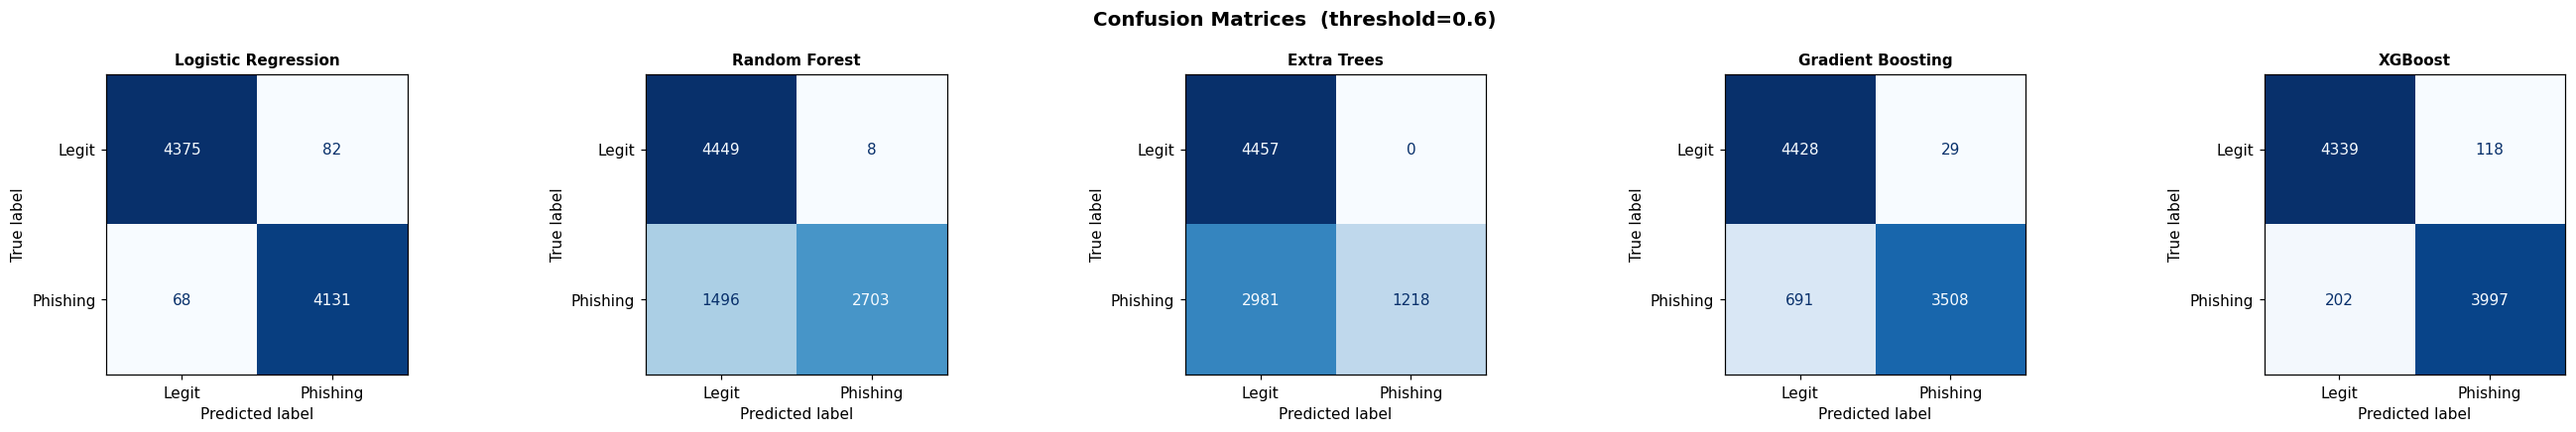

In [ ]:
# ── CELL 11 — Confusion matrices ─────────────────────────────────────────────
n_m = len(pipelines)
fig, axes = plt.subplots(1, n_m, figsize=(5*n_m, 4))
if n_m == 1: axes = [axes]
fig.suptitle(f'Confusion Matrices  (threshold={THRESHOLD})', fontsize=13, fontweight='bold')
for ax, name in zip(axes, pipelines):
    yp = pipelines[name].predict_proba(X_test)[:, 1]
    yh = (yp >= THRESHOLD).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, yh),
                           display_labels=['Legit','Phishing']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

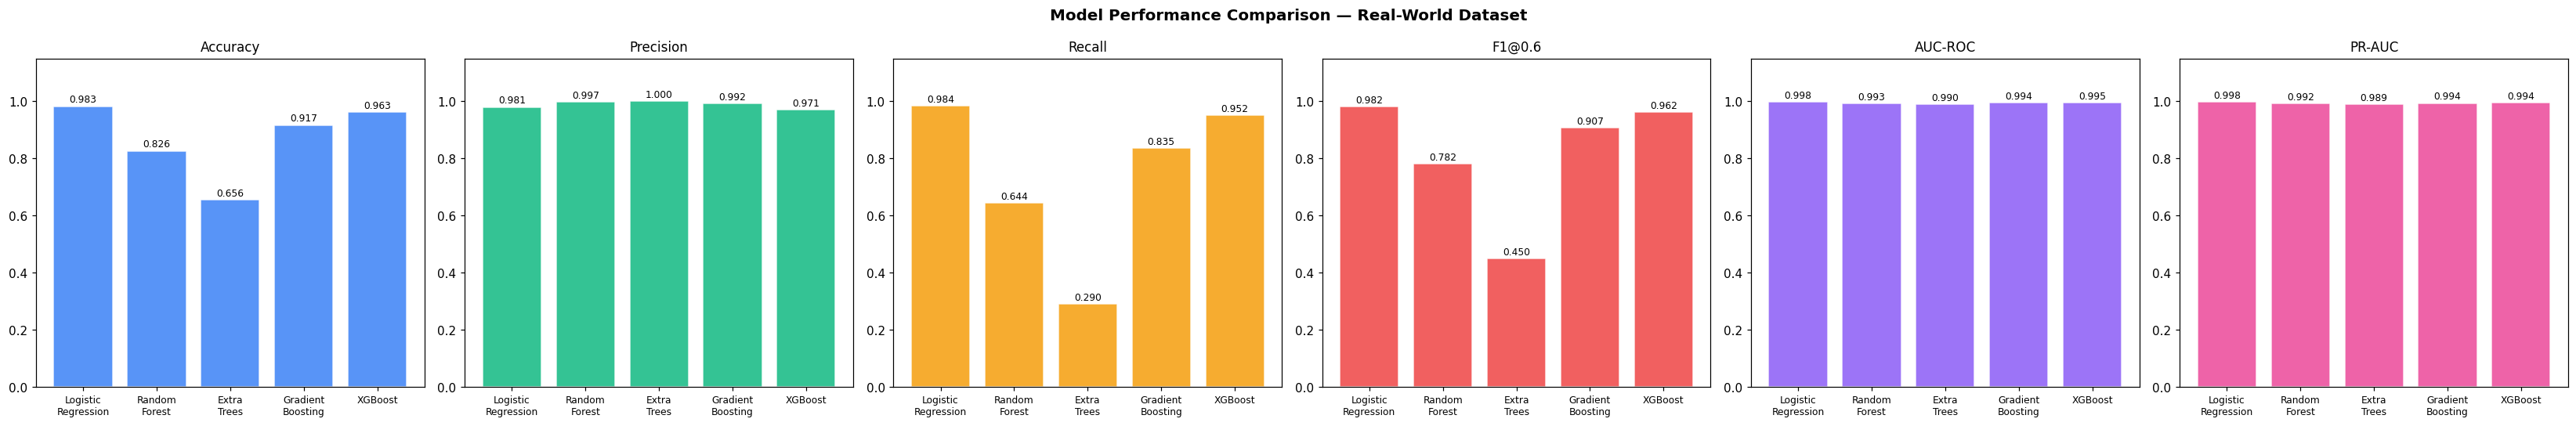

In [ ]:
# ── CELL 12 — Metric bar charts ──────────────────────────────────────────────
model_names = list(results.keys())
short_names = [n.replace(' ','\n') for n in model_names]
met_keys   = ['accuracy','precision','recall',f'f1_at_{THRESHOLD}','auc','average_precision']
met_labels = ['Accuracy','Precision','Recall',f'F1@{THRESHOLD}','AUC-ROC','PR-AUC']
colors     = ['#3B82F6','#10B981','#F59E0B','#EF4444','#8B5CF6','#EC4899']
fig, axes = plt.subplots(1, len(met_keys), figsize=(5*len(met_keys), 5))
fig.suptitle('Model Performance Comparison — Real-World Dataset', fontsize=13, fontweight='bold')
for ax, key, label, color in zip(axes, met_keys, met_labels, colors):
    vals = [results[n][key] for n in model_names]
    bars = ax.bar(short_names, vals, color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, 1.15); ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()

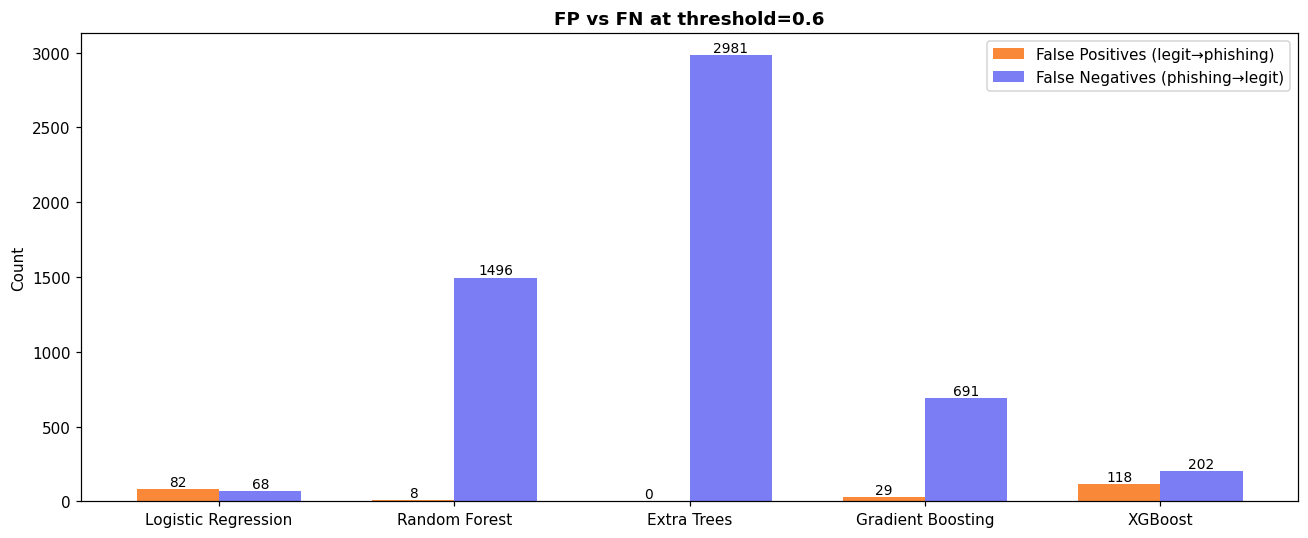

In [ ]:
# ── CELL 13 — FP vs FN comparison ───────────────────────────────────────────
fp_vals = [results[n][f'fp_at_{THRESHOLD}'] for n in model_names]
fn_vals = [results[n][f'fn_at_{THRESHOLD}'] for n in model_names]
x = np.arange(len(model_names)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x-w/2, fp_vals, w, label='False Positives (legit→phishing)', color='#F97316', alpha=0.85)
b2 = ax.bar(x+w/2, fn_vals, w, label='False Negatives (phishing→legit)', color='#6366F1', alpha=0.85)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_title(f'FP vs FN at threshold={THRESHOLD}', fontsize=12, fontweight='bold')
ax.set_ylabel('Count'); ax.legend(); plt.tight_layout(); plt.show()

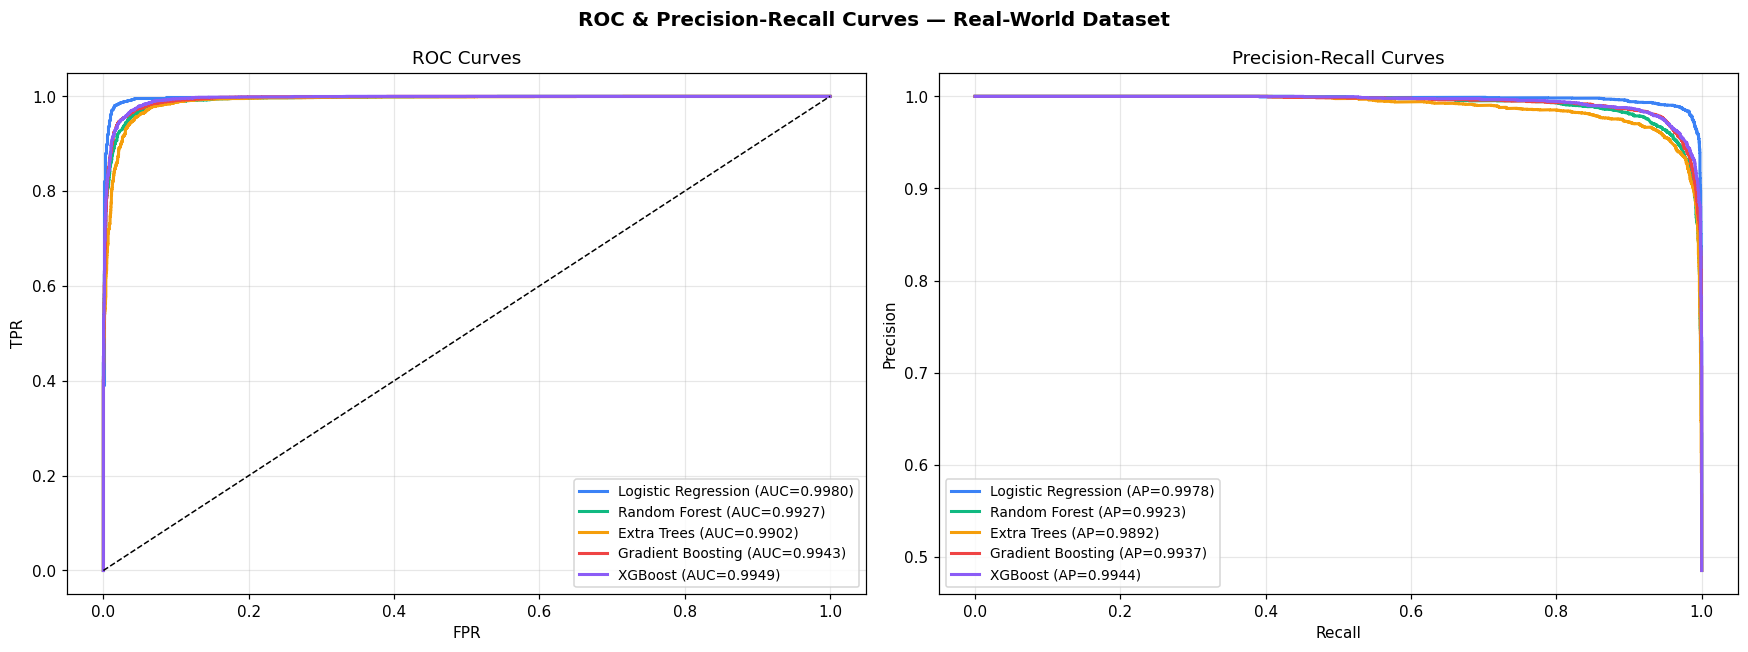

In [ ]:
# ── CELL 14 — ROC & Precision-Recall curves ──────────────────────────────────
colors_roc = ['#3B82F6','#10B981','#F59E0B','#EF4444','#8B5CF6']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC & Precision-Recall Curves — Real-World Dataset', fontsize=13, fontweight='bold')
for (name, pipe), color in zip(pipelines.items(), colors_roc):
    yp = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={results[name]["auc"]:.4f})')
    pc, rc, _ = precision_recall_curve(y_test, yp)
    ap = results[name]['average_precision']
    ax2.plot(rc, pc, color=color, lw=2, label=f'{name} (AP={ap:.4f})')
ax1.plot([0,1],[0,1],'k--',lw=1); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curves'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# ── CELL 15 — Final comparison table ─────────────────────────────────────────
rows = []
for name in model_names:
    r = results[name]
    rows.append({
        'Model': name, 'AUC': r['auc'], 'PR-AUC': r['average_precision'],
        'Accuracy': r['accuracy'], 'Precision': r['precision'],
        'Recall': r['recall'], f'F1@{THRESHOLD}': r[f'f1_at_{THRESHOLD}'],
        'FP': r[f'fp_at_{THRESHOLD}'], 'FN': r[f'fn_at_{THRESHOLD}'],
        'Best?': '★' if name == best_name else '',
    })
summary_df = pd.DataFrame(rows).set_index('Model')
print('=== FINAL MODEL COMPARISON ===\n')
display(summary_df.style
    .highlight_max(subset=['AUC','PR-AUC','Accuracy','Precision','Recall',f'F1@{THRESHOLD}'], color='#d4edda')
    .format(precision=4))

=== FINAL MODEL COMPARISON ===



,AUC,PR-AUC,Accuracy,Precision,Recall,F1@0.6,FP,FN,Best?
Model,,,,,,,,,
Logistic Regression,0.9980,0.9978,0.9827,0.9805,0.9838,0.9822,82,68,★
Random Forest,0.9927,0.9923,0.8262,0.9970,0.6437,0.7823,8,1496,
Extra Trees,0.9902,0.9892,0.6556,1.0000,0.2901,0.4497,0,2981,
Gradient Boosting,0.9943,0.9937,0.9168,0.9918,0.8354,0.9069,29,691,
XGBoost,0.9949,0.9944,0.9630,0.9713,0.9519,0.9615,118,202,


In [ ]:
# ── CELL 16 — Save best model (identical format to train.py) ─────────────────
import joblib, os

save_path = '/content/phishing_detection.pkl'

meta = {
    'model_name':        best_name,
    'threshold':         THRESHOLD,
    'f1':                results[best_name][f'f1_at_{THRESHOLD}'],
    'auc':               results[best_name]['auc'],
    'average_precision': results[best_name]['average_precision'],
    'datasets_used':     ALL_CSV_FILES,
    'total_rows':        len(df),
    'results_all':       results,
}

joblib.dump({'pipeline': pipelines[best_name], 'meta': meta}, save_path, compress=3)
print(f'✓ Saved → {save_path}')
print(f'  Best model : {best_name}')
print(f'  F1@{THRESHOLD}    : {meta["f1"]:.4f}')
print(f'  AUC        : {meta["auc"]:.4f}')
print(f'  PR-AUC     : {meta["average_precision"]:.4f}')
print()
print('Download phishing_detection.pkl and place it in your models/ folder.')

# Optional: also save to Drive if mounted
try:
    drive_path = '/content/drive/MyDrive/phishing_detection.pkl'
    if os.path.isdir('/content/drive/MyDrive'):
        import shutil; shutil.copy(save_path, drive_path)
        print(f'✓ Also saved to Drive → {drive_path}')
except Exception as e:
    print(f'Drive save skipped: {e}')

✓ Saved → /content/phishing_detection.pkl
  Best model : Logistic Regression
  F1@0.6    : 0.9822
  AUC        : 0.9980
  PR-AUC     : 0.9978

Download phishing_detection.pkl and place it in your models/ folder.
